In [1]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from langchain.tools import tool
load_dotenv()

if os.environ['GOOGLE_API_KEY'] == "":
    raise ValueError("GOOGLE_API_KEY is not set in the .env file.")
else:
    print("GOOGLE_API_KEY is set correctly.")

GOOGLE_API_KEY is set correctly.


In [2]:
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite",)
llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13', 'langchain-google-genai': '4.2.6'}}, output_version=None, profile={'name': 'Gemini 3.1 Flash Lite', 'release_date': '2026-05-07', 'last_updated': '2026-05-07', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.1-flash-lite', temperature=1.0, client=<google.genai.client.Client object at 0x00000146FB8AA5C0>, default_metadata=(), model_kwargs={})

In [3]:
from pydantic import BaseModel, Field
from typing import Literal

class llm_schema(BaseModel):
    category: Literal["insta", "twitter", "linkedin"] = Field(..., description="The category of the social media platform to generate post for.")
    topic: str = Field(..., description="The topic of the post to generate.")

In [4]:
llm_with_schema = llm.with_structured_output(llm_schema)

In [5]:
class graph_schema(BaseModel):
    input: str = Field(..., description="The input from user.")
    category: str = Field(..., description="The category of social media post to generate.")
    topic: str = Field(..., description="The topic of the post to generate.")
    post: str = Field(..., description="The generated post.")    

In [6]:
def generate_linkedin_post(state: graph_schema) -> graph_schema:

    state = state.model_dump()  # Convert the Pydantic model to a dictionary

    topic = state['topic']

    linkedin_post = llm.invoke(f'Write a LinkedIn post about {topic} in 30 words. Keep the tone professional.').content[0].get('text')
    state['post'] = linkedin_post

    return state


def generate_insta_post(state: graph_schema) -> graph_schema:

    state = state.model_dump()  # Convert the Pydantic model to a dictionary

    topic = state['topic']

    insta_post = llm.invoke(f'Write an Instagram post about {topic} in 30 words. Keep the tone engaging.').content[0].get('text')
    state['post'] = insta_post

    return state


def generate_twitter_post(state: graph_schema) -> graph_schema:

    state = state.model_dump()  # Convert the Pydantic model to a dictionary

    topic = state['topic']

    twitter_post = llm.invoke(f'Write a Twitter post about {topic} in 30 words. Keep the tone concise.').content[0].get('text')
    state['post'] = twitter_post

    return state

In [7]:
def decider_node(state: graph_schema) -> graph_schema:

    state = state.model_dump()

    input = state["input"]
    result = llm_with_schema.invoke(input)
    

    state['category'] = result.category
    state['topic'] = result.topic
    return state

In [8]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("decider", decider_node)
graph.add_node("insta_post", generate_insta_post)
graph.add_node("linkedin_post", generate_linkedin_post)
graph.add_node("twitter_post", generate_twitter_post)

In [9]:
def condition(state: graph_schema) -> str:
    state = state.model_dump()
    
    category = state['category']

    if category == 'insta':
        return 'insta_post'
    elif category == "linkedin":
        return "linkedin_post"
    elif category == "twitter":
        return "twitter_post"
    else:
        raise ValueError("Invalid category")

In [10]:
graph.add_edge(START, "decider")
graph.add_conditional_edges(
    "decider",
    condition,
    {
        "insta_post": "insta_post",
        "linkedin_post": "linkedin_post",
        "twitter_post": "twitter_post",
    },
)
graph.add_edge("insta_post", END)
graph.add_edge("linkedin_post", END)
graph.add_edge("twitter_post", END)

route_graph = graph.compile()

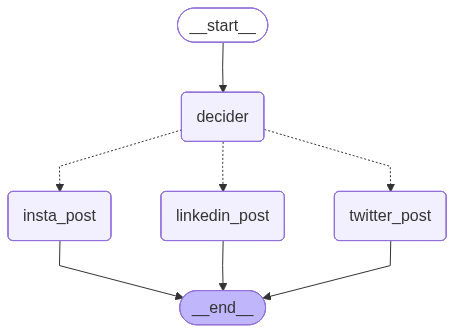

In [11]:
from IPython.display import Image, display

Image(route_graph.get_graph().draw_mermaid_png())

In [12]:
route_graph.invoke({
    "input": "I want to generate a post about 'rising trendsin AI' on linkedin.",
    "topic": "",
    "category": "",
    "post": ""
})

{'input': "I want to generate a post about 'rising trendsin AI' on linkedin.",
 'category': 'linkedin',
 'topic': 'rising trends in AI',
 'post': 'AI is rapidly evolving, with generative tools and autonomous agents transforming workflows. Staying competitive requires embracing these innovations to drive efficiency and unlock new strategic value in your industry.'}